In [3]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv("/content/TASK 3 Symptom2Disease.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [4]:
# Check dataset shape

df.shape

(1200, 3)

In [6]:
# Separate input and output

X = df.drop('label', axis='columns')
y = df['label']

In [7]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [9]:
# Try different K values

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit the vectorizer on the training text data and transform both train and test sets
X_train_transformed = vectorizer.fit_transform(X_train['text'])
X_test_transformed = vectorizer.transform(X_test['text'])

k_values = [1,3,5,7,9]

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    # Use the transformed (numerical) data for fitting and scoring
    model.fit(X_train_transformed, y_train)

    score = model.score(X_test_transformed, y_test)

    print("K =", k, "Accuracy =", score)

K = 1 Accuracy = 0.9666666666666667
K = 3 Accuracy = 0.9208333333333333
K = 5 Accuracy = 0.9125
K = 7 Accuracy = 0.9
K = 9 Accuracy = 0.8833333333333333


In [11]:
# Final KNN model

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train_transformed, y_train)

KNeighborsClassifier(n_neighbors=3)

In [13]:
# Accuracy of final model

print(model.score(X_test_transformed, y_test))

0.9208333333333333


In [15]:
# Predictions

y_pred = model.predict(X_test_transformed)

print(y_pred[:10])

['Bronchial Asthma' 'Hypertension' 'gastroesophageal reflux disease'
 'Chicken pox' 'drug reaction' 'Dengue' 'Jaundice' 'Fungal infection'
 'Arthritis' 'Hypertension']


In [16]:
# Actual values

print(y_test[:10].values)

['Bronchial Asthma' 'Hypertension' 'gastroesophageal reflux disease'
 'Chicken pox' 'drug reaction' 'Dengue' 'Jaundice' 'Fungal infection'
 'Arthritis' 'Hypertension']


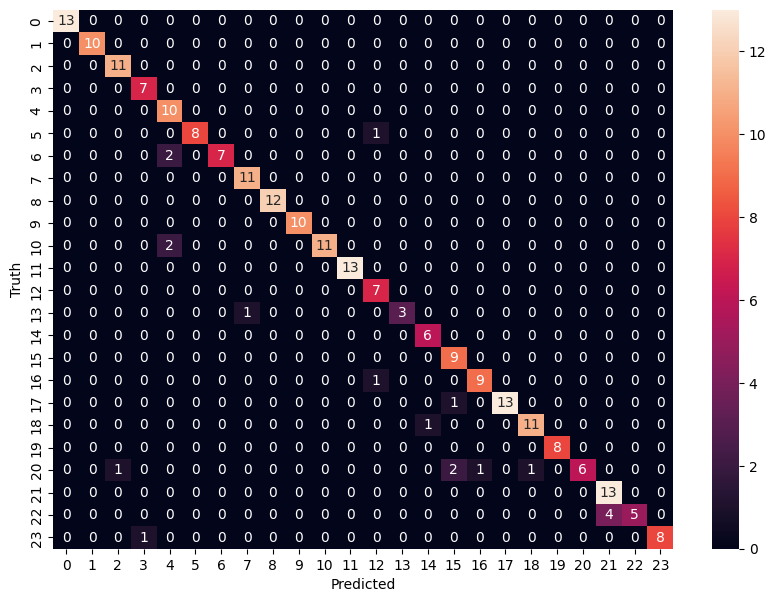

In [17]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.show()

In [18]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        13
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       0.92      1.00      0.96        11
           Cervical spondylosis       0.88      1.00      0.93         7
                    Chicken pox       0.71      1.00      0.83        10
                    Common Cold       1.00      0.89      0.94         9
                         Dengue       1.00      0.78      0.88         9
          Dimorphic Hemorrhoids       0.92      1.00      0.96        11
               Fungal infection       1.00      1.00      1.00        12
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      0.85      0.92        13
                       Jaundice       1.00      1.00      1.00        13
                        Malaria       0.78      1.

In [20]:
# Predict disease for new patient
# Change values according to your symptoms dataset

# Example of new symptoms as a text string
new_symptom_text = ["I have a dry cough, sore throat, and a high fever."]

# Transform the new symptom text using the trained vectorizer
sample_transformed = vectorizer.transform(new_symptom_text)

prediction = model.predict(sample_transformed)

print("Predicted Disease :", prediction[0])

Predicted Disease : Bronchial Asthma
